# Machine Learning Explainability (XAI) - A Simple Coding Tutorial #

Machine Learning Explainability, commonly referred to as XAI (Explainable Artificial Intelligence), addresses the challenge of trusting AI/ML predictions by providing methods and tools to interpret, understand, and trust the decisions made by machine learning models.

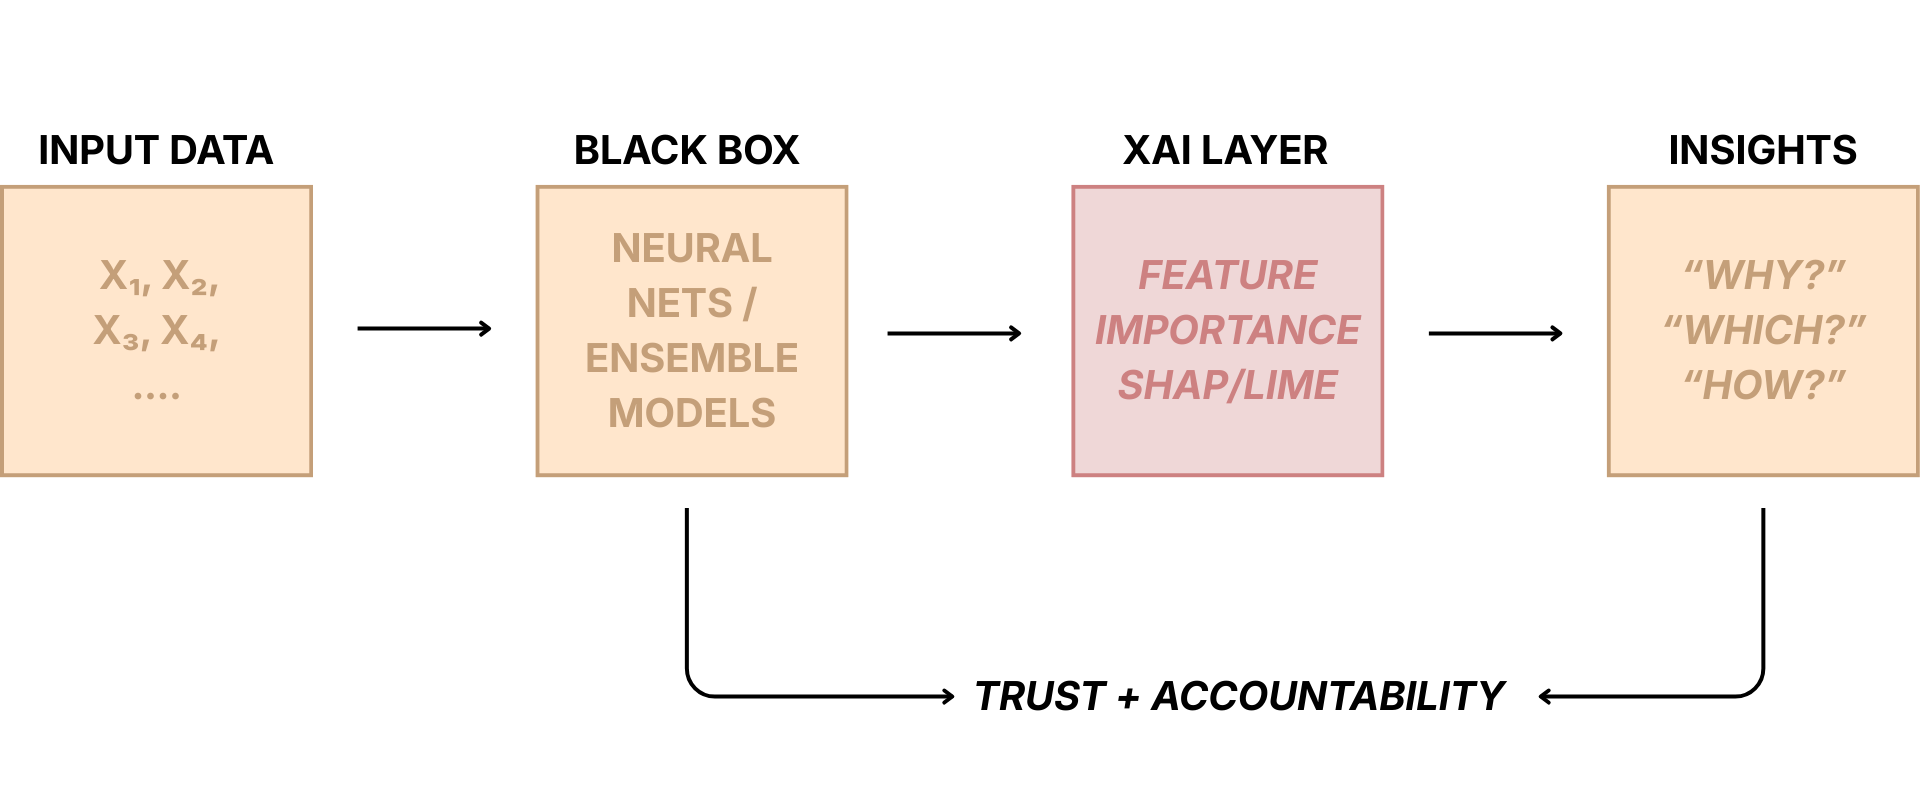

## In the main article we saw that there are two main methods to interpet model predictions: ##
1) Local explanations
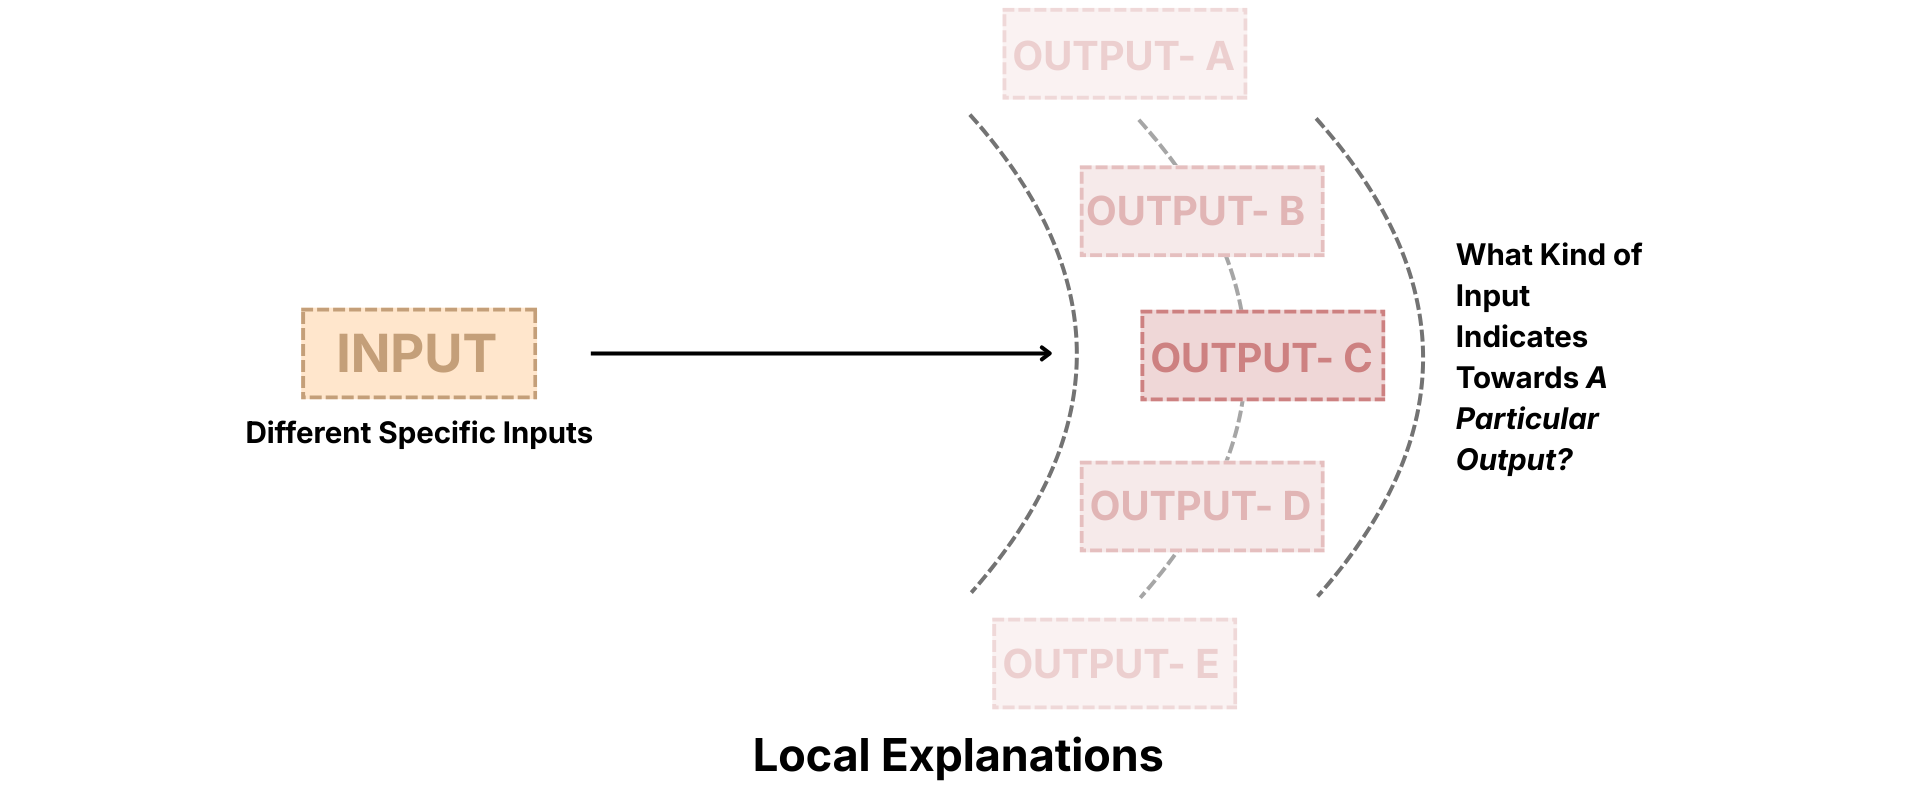

2) Global explanations
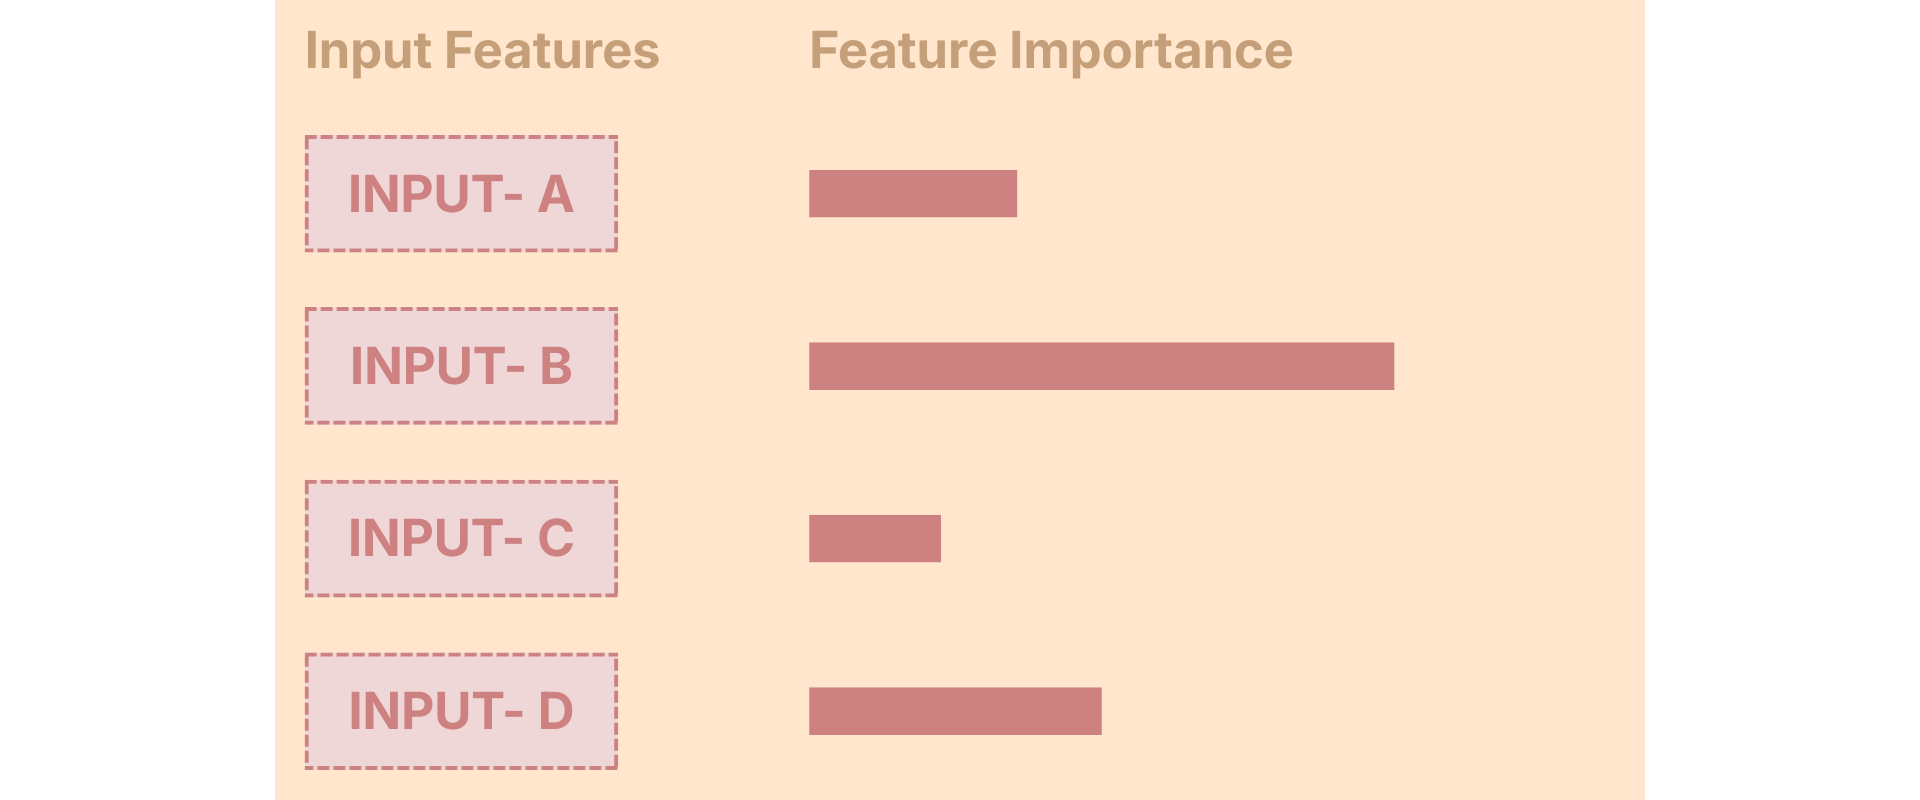


Therefore, in this coding tutorial we will:
1) Train a simple classifier
2) Explain it using feature importance
3) Use LIME for local explanations
4) Use SHAP for both local and gobal explanations

In [ ]:
pip install numpy matplotlib scikit-learn shap lime


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import lime
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


We will use a 'Breast cancer dataset' which is a small, tabular and well-known dataset and ideal for explainability demonstrations.
We will also perform classification using a 'RandomForest Classifier', its a strong model but sometimes not easily interpretable.

In [ ]:
# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.9649122807017544


We now have a black-box classifier that performs well but we don't yet know why it makes it's decisions.

## Global Feature Importance ##

By computing global feature importance we can find:
* Which features matter on average
* Simple but limited explanations
* Global importance i.e. no explanations for individual features

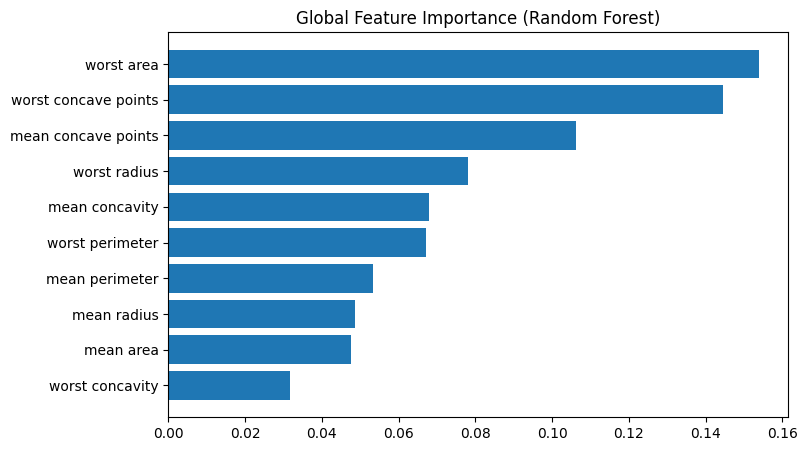

In [ ]:
importances = model.feature_importances_
indices = np.argsort(importances)[-10:]

plt.figure(figsize=(8,5))
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), feature_names[indices])
plt.title("Global Feature Importance (Random Forest)")
plt.show()


## Local Explainability with LIME ##

LIME explains one prediction at a time.

In [ ]:
from lime.lime_tabular import LimeTabularExplainer

explainer = LimeTabularExplainer(
    X_train,
    feature_names=feature_names,
    class_names=data.target_names,
    discretize_continuous=True
)


Explain a single pediction:

In [ ]:
i = 5  # index of test sample

exp = explainer.explain_instance(
    X_test[i],
    model.predict_proba,
    num_features=8
)

exp.show_in_notebook()


The above and below results from LIME show:
* Which features pushed the prediction toward *begnin* or *malignant*
* Approximate, local, intuitive and human readable explanations


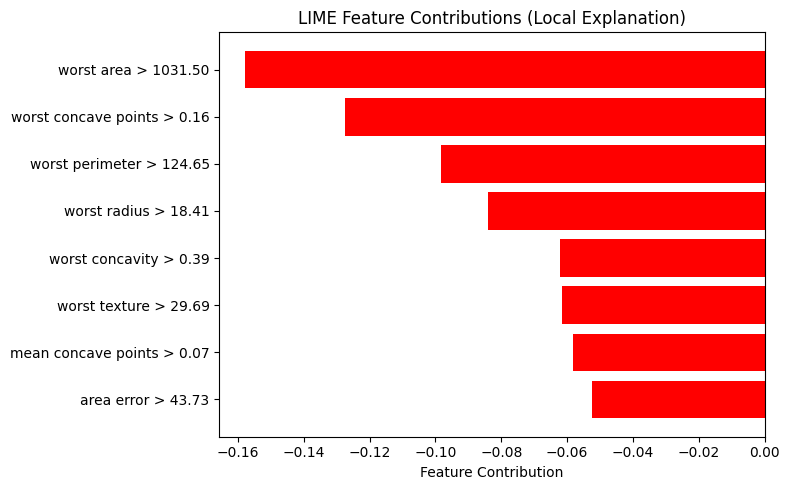

In [ ]:
# Extract explanation data
explanation = exp.as_list()

features = [f[0] for f in explanation]
weights = [f[1] for f in explanation]

plt.figure(figsize=(8,5))
colors = ['red' if w < 0 else 'blue' for w in weights]

plt.barh(features, weights, color=colors)
plt.xlabel("Feature Contribution")
plt.title("LIME Feature Contributions (Local Explanation)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## SHAP - unified global + local explanations ##

As we saw in the main article, SHAP explains predictions using Shapley values from *game theory*.

In [ ]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)


<Figure size 800x100 with 0 Axes>

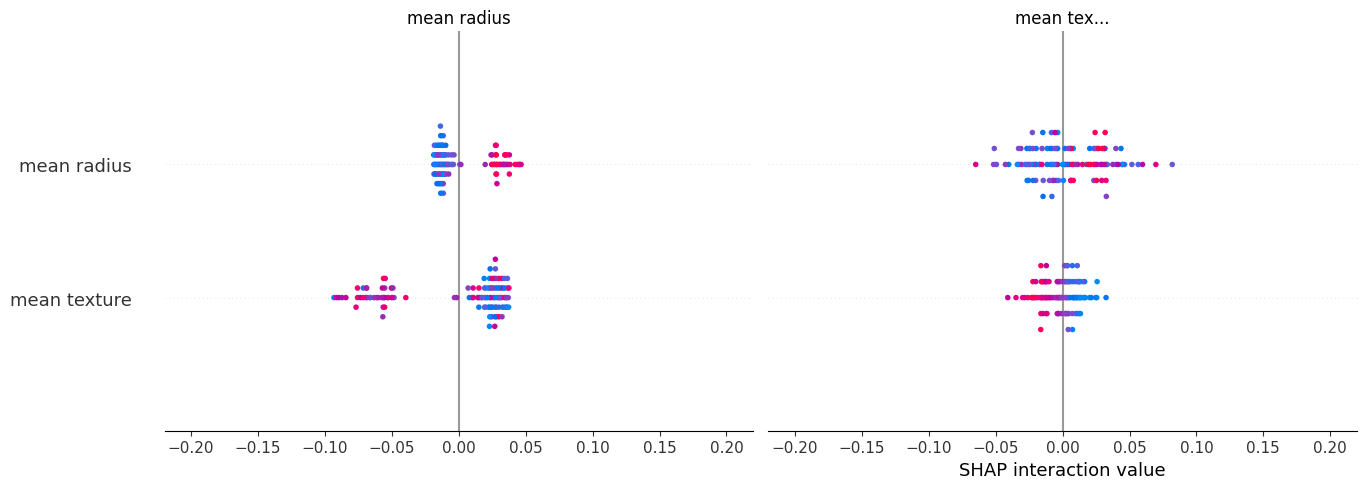

In [ ]:
plt.figure(figsize=(8, 1))
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=feature_names,
    max_display=8,
    show=False
)
plt.gcf().set_size_inches(50, 5)
plt.tight_layout()
plt.show()

In the above plots we can observe feature importance across all samples for two selected features namely 'mean radius' and 'mean texture'.

The plots show how each feature contributed to one prediction:
* Red -> pushes toward malignant
* Blue -> pushes toward benign

The plots also show the direction of influence (positive vs negative).

In conclusion, what do all the results demonstrate?

* Feature importance gives a rough global overview
* LIME explains individual decisions locally
* SHAP provides consistent global and local explanations
* It is important to note that different methods answer different questions


When should each method be used?
* Use fetaure importance for quick global insights
* Use LIME for user-facing, case-by-case explanations
* Use SHAP for research, auditing, and robust analysis


Explainability does not replace model evaluation but complements it!

XAI helps us understand how and why models make decisions, enabling safer, more transparent and more trustworthy machine learning systems.